In [279]:
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import polars.selectors as cs


## Loading and Standardization

In [280]:
# Load the data
tep_fault_free = pl.read_parquet("../data/tep_fault_free_training.parquet")
tep_faulty = pl.read_parquet("../data/tep_faulty_training_runs01-20.parquet")

In [281]:
# Define global variables
RUN = "simulationRun"

In [282]:
# Define preprocessing functions
def channels(df): # Get the list of channels
    lst = df.drop(["faultNumber", "simulationRun", "sample"])
    lst_channels = lst.columns
    return lst_channels

In [283]:
def training_runs(df): # faulty free
    train = df.filter(pl.col(RUN) <= 300)
    return train

def validation_runs(df): # faulty free
    validation = df.filter((pl.col(RUN) >= 301) & (pl.col(RUN) <= 400))
    return validation

def test_runs(df): # fault free
    test = df.filter((pl.col(RUN) >= 401) & (pl.col(RUN) <= 500))
    return test

In [284]:
def standardization(df, lst_channels): # standardize the data set
    # compute the mean for each column
    train = training_runs(df)
    mean = []
    std_dev = []
    for channel in lst_channels:
        mean.append(train.select(pl.col(channel).mean()).item()) #get the exact value
        std_dev.append(train.select(pl.col(channel).std(ddof=1)).item()) 
    return mean, std_dev

def apply_standard(df, lst_channels, mean, std_dev): # take in any df (i.e. training, validation, test)
    standardized = df
    for i in range(len(lst_channels)):
        standardized = standardized.with_columns(pl.col(lst_channels[i]).sub(mean[i]) / std_dev[i])
    return standardized

In [285]:
def main():
    chan = channels(tep_fault_free) # list of channel names for tracked variables
    mean, std_dev = standardization(tep_fault_free, chan) # distribution of fault free data

    train = training_runs(tep_fault_free) # define training set (1-300)
    val = validation_runs(tep_fault_free) # define validation set (301-400)
    test = test_runs(tep_fault_free) # define test set (401-500)

    # Four standardized data frames for the training, validation, test, and faulty runs
    train_standardized = apply_standard(train, chan, mean, std_dev)
    val_standardized = apply_standard(val, chan, mean, std_dev)
    test_standardized = apply_standard(test, chan, mean, std_dev)
    faulty_standardized = apply_standard(tep_faulty, chan, mean, std_dev)
    


if __name__ == "__main__":
    main()

## PCA

In [286]:
# get data for PCA 

chan = channels(tep_fault_free) # list of channel names for tracked variables
mean, std_dev = standardization(tep_fault_free, chan) # distribution of fault free data

train = training_runs(tep_fault_free) # define training set (1-300)

train_standardized = apply_standard(train, chan, mean, std_dev)

In [287]:
# create the covariance matrix 

train_standardized = train_standardized.drop(cs.by_index([0,1,2])) # only want covariance under normal operation of the data, not the run numbers

pca = PCA() # use PCA on the shortened test data
pca.fit(train_standardized)

covariance = pca.get_covariance() # used to examine and see what variables are related 

eigenvalues = pca.explained_variance_ # raw eigenvalues that explain variance

scaled_eigenvalues = pca.explained_variance_ratio_ # scaled, so they sum to one

In [ ]:
cumulative = np.cumsum(scaled_eigenvalues) # keeps a cumulative sum of eigenvalues

k = int(np.argmax(cumulative >= 0.90) + 1) # counts up the number of scaled eigenvalues until it reaches 90%
print("k =", k)

lam_k = eigenvalues[:k] # raw eigenvalues of top k PCs
# P = pca.components_[:k].T # eigenvectors of the top k PCs

k = 31


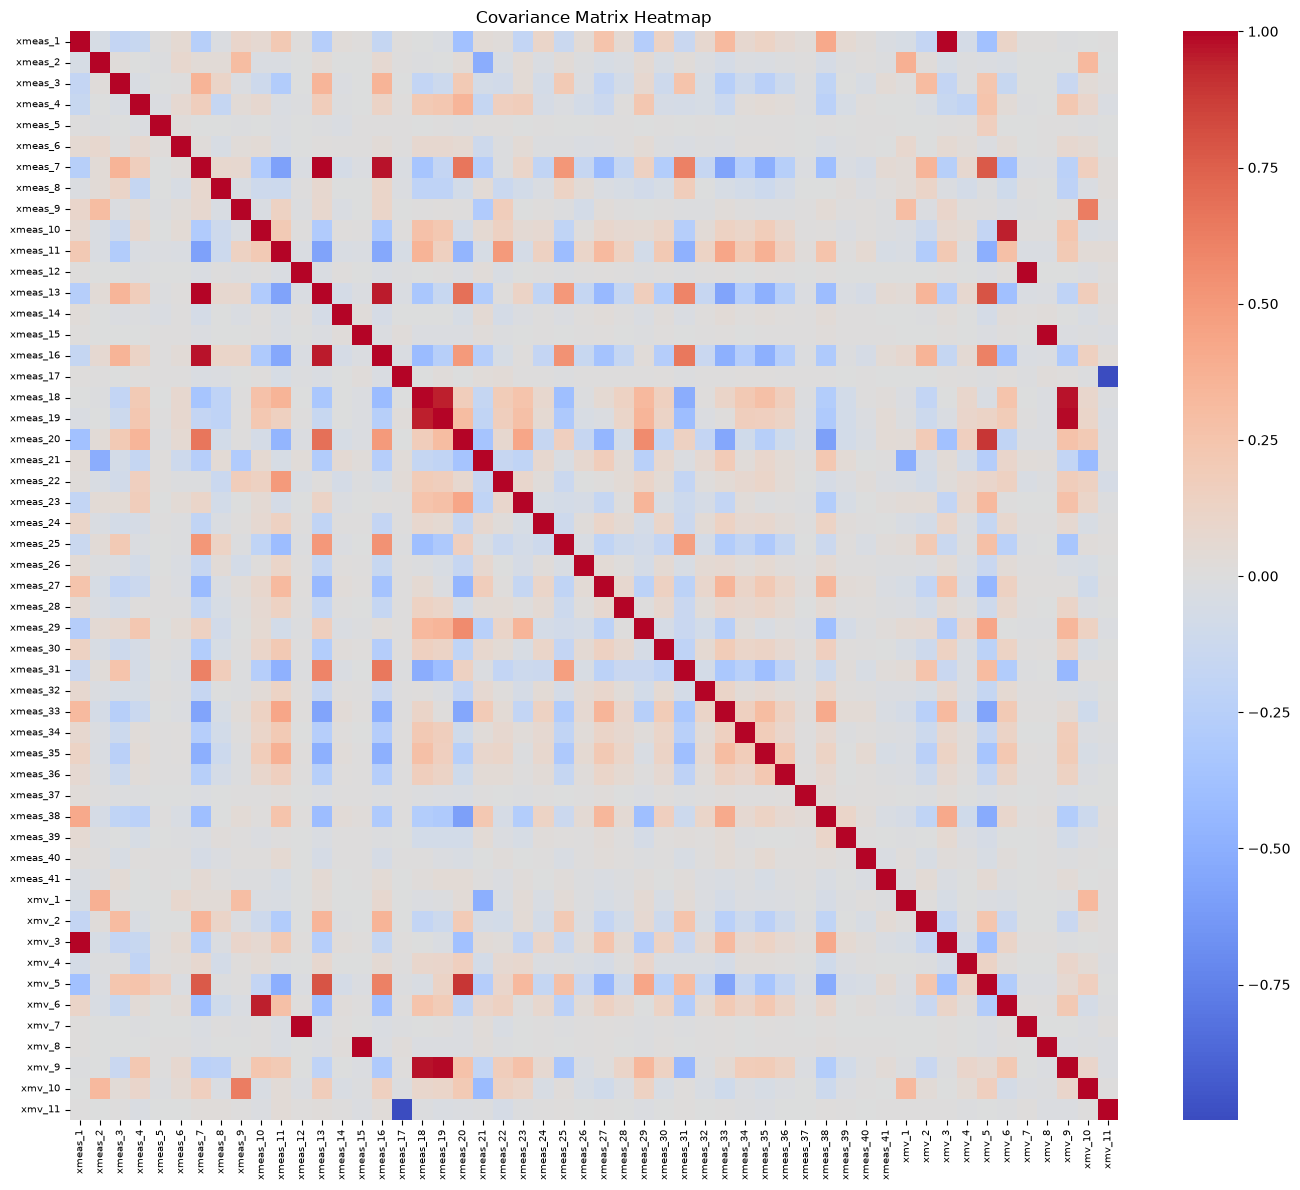

In [295]:
corr = pd.DataFrame(covariance, index=chan, columns=chan )
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(corr, cmap='coolwarm', xticklabels=True, yticklabels=True)
ax.tick_params(labelsize=7)
plt.title('Covariance Matrix Heatmap')
plt.tight_layout()
plt.show()

**Need to score each standardized row, representing how "normal" compared to fault-free operation, judged by how much of the variance is explained in the same directions. Then write a parquet file with this scoring**